In [1]:
import matplotlib as mpl
from scipy.optimize import minimize
%matplotlib inline
# Set the font to Times New Roman or a similar serif font
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
# Adjust the text sizes
mpl.rcParams['axes.labelsize'] = 10  # For X and Y axis labels
mpl.rcParams['axes.titlesize'] = 10  # For the plot title
mpl.rcParams['legend.fontsize'] = 10 # For the legend


from utils import *


Processing: 100%|██████████| 463/463 [00:11<00:00, 39.51it/s]


phase at the last time step: [1.58437266]


Processing: 100%|██████████| 463/463 [00:11<00:00, 40.19it/s]


phase at the last time step: [1.18818828]


Processing: 100%|██████████| 474/474 [00:11<00:00, 40.62it/s]


phase at the last time step: [-1.890425]


Processing: 100%|██████████| 474/474 [00:11<00:00, 40.97it/s]
 /var/folders/yv/8f1w22v95lj4r3b_62lwrtvr0000gn/T/ipykernel_77494/2491357253.py: 66

phase at the last time step: [-2.03192656]


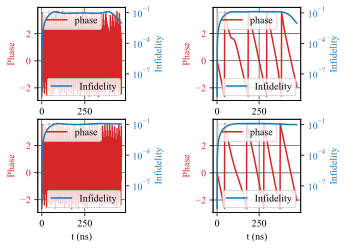

In [8]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*1.7))
gs = gridspec.GridSpec(3,2, width_ratios=[1, 1], height_ratios=[1,1,1],wspace=1.0,hspace=0.2)
for i, filename in enumerate([
            'pickles/mesolve_01_reference_states_two_level.pkl',
            'pickles/mesolve_12_reference_states_two_level.pkl'
        ]):
    with open(filename, 'rb') as file:
        results_combined = pickle.load(file)
    for j, (kappa, results) in enumerate(zip([1e-3,1e-2],[results_combined[0:4],results_combined[4:]])):
        ax1 = plt.subplot(gs[j,i])
        num_initial_states = len(results)
        num_time_steps = len(results[0].times)
        # distinguish the results for different kappa
        infidelity = []
        phase = []
        for idx in tqdm(range(num_time_steps), desc='Processing'):
            dms = [result.states[idx] for result in results]
            def objective_function(phase):
                return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
            initial_phase = [0.0]
            bounds = [(0, 2 * 3.141592653589793)]
            opt_result = minimize(objective_function, initial_phase,method="COBYLA")
            infidelity.append(opt_result.fun)
            phase.append(opt_result.x)
        with open(f'pickles/mesolve_reference_states_{i}{j}_(infidelity,phase).pkl', 'wb') as file:
            pickle.dump((infidelity,phase), file)
        with open(f'pickles/mesolve_reference_states_{i}{j}_(infidelity,phase).pkl', 'rb') as file:
            (infidelity,phase) = pickle.load(file)
        color = 'tab:red'
        ax1.plot(results[0].times,phase,label = 'phase',color = color)
        ax1.set_ylabel('Phase', color=color)
        ax1.set_xlabel("t (ns)")
        ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
        # ax1.minorticks_on()
        # ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.legend(loc='upper left')

        ax2 = ax1.twinx()
        color = 'tab:blue'
        ax2.set_ylabel('Infidelity', color=color)
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
        ax2.legend(loc='lower right')
        ax2.set_yscale('log')

        print(f'phase at the last time step: {phase[-1]}')
fig.tight_layout()  # For a nicer layout
plt.show()

Processing:   0%|          | 0/463 [00:00<?, ?it/s]

Processing: 100%|██████████| 463/463 [00:15<00:00, 29.31it/s]
 /tmp/ipykernel_203565/1773189599.py: 59WARNING:matplotlib.font_manager:findfont: Font family 'Times New Roman' not found.


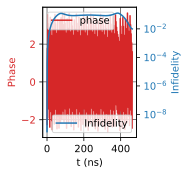

In [50]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - one).unit() ]
def calc_average_fidelity_with_phase(phase,dms,states_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    fid=[]
    for dm,ket_ideal in zip(dms,states_ideal):
        # new_dm = gate*dm*gate.dag()
        fid.append(qutip.fidelity(dm, gate*ket_ideal))
    return 1-sum(fid)/len(fid)


colors = [(0.9, 0.9, 0.4), (0.5*0.5, 0.7*0.5, 0.5*0.5), (0.7, 0.6, 0.7)]
linestyles = [(0,(3,1,1,1)),'-',(0,(5,2,5,2))]
fig = plt.figure(figsize=((3+3/8)*1.4, 
                            (3+3/8)*0.7))
gs = gridspec.GridSpec(1,2, width_ratios=[1, 1], wspace=0.8)

filename =  'pickles/mesolve_01_reference_states_two_level.pkl'
with open(filename, 'rb') as file:
    results_combined = pickle.load(file)
results = results_combined[0:4]
ax1 = plt.subplot(gs[0,i])
num_initial_states = len(results)
num_time_steps = len(results[0].times)
# distinguish the results for different kappa
infidelity = []
phase = []
for idx in tqdm(range(num_time_steps), desc='Processing'):
    dms = [result.states[idx] for result in results]
    def objective_function(phase):
        return calc_average_fidelity_with_phase(phase[0], dms, states_ideal)
    initial_phase = [0.0]
    bounds = [(-3.141592653589793,  3.141592653589793)]
    opt_result = minimize(objective_function, initial_phase,method="COBYLA")
    infidelity.append(opt_result.fun)
    phase.append(opt_result.x)

color = 'tab:red'
ax1.plot(results[0].times,phase,label = 'phase',color = color)
ax1.set_ylabel('Phase', color=color)
ax1.set_xlabel("t (ns)")
ax1.grid(which='major', linestyle='-', linewidth='0.5', color='black')
# ax1.minorticks_on()
# ax1.grid(which='minor', linestyle='--', linewidth='0.5', color='gray')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Infidelity', color=color)
ax2.tick_params(axis='y', labelcolor=color)
ax2.plot(results[0].times,infidelity,label = 'Infidelity',color = color)
ax2.legend(loc='lower right')
ax2.set_yscale('log')
fig.tight_layout()  # For a nicer layout
plt.show()

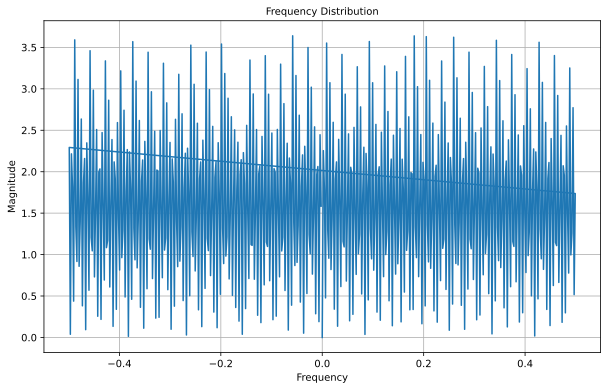

In [51]:
data = phase
fft_result = np.fft.fft(data)

# Compute the frequencies
sample_spacing = 1  # Assuming a sample spacing of 1
freqs = np.fft.fftfreq(len(data), d=sample_spacing)

# Compute the magnitude of the FFT results
magnitude = np.abs(fft_result)

# Plot the frequency distribution
plt.figure(figsize=(10, 6))
plt.plot(freqs, magnitude)
plt.title('Frequency Distribution')
plt.xlabel('Frequency')
plt.ylabel('Magnitude')
plt.grid(True)
plt.show()